In [1]:
import os
import locale
import modal
from agents.preprocessor import Preprocessor
from dotenv import load_dotenv
load_dotenv(override=True)

C:\Users\aksha\PycharmProjects\PricerProje\venv\Lib\site-packages\modal\_utils\async_utils.py:42: DeprecationWarning: 'asyncio.WindowsSelectorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
C:\Users\aksha\PycharmProjects\PricerProje\venv\Lib\site-packages\modal\_utils\async_utils.py:42: DeprecationWarning: 'asyncio.set_event_loop_policy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())


False

In [2]:
print(locale.getpreferredencoding())


cp1252


In [3]:
os.environ["PYTHONIOENCODING"] = "utf-8"

In [4]:
from hello import app, hello, hello_europe
with app.run():
    reply=hello.local()
reply
with app.run():
    reply=hello.remote()
reply

'Hello from Dulles Town Center, Virginia, US!!'

In [5]:
# This import may give a deprecation warning about adding local Python modules to the Image
# That warning can be safely ignored. You may get the same warning in other places, too..

import importlib
import llama
importlib.reload(llama)
from llama import generate
price_prompt = """What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal
Category: Music Pedals
Brand: Old Blood Noise
Description: A versatile pedal offering distortion, delay, chorus, and harmonized fifths.
Details: Separate gain, tone, volume, time, and depth controls with expression jack.

Price is $"""

result = generate(price_prompt)
result

W0804 09:50:45.734000 13492 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


'100.00'

In [6]:
import importlib
import pricer_ephemeral
importlib.reload(pricer_ephemeral)
from pricer_ephemeral import price
result = price("Quadcast HyperX condenser mic, connects via usb-c to your computer for crystal clear audio")
result

100.0

In [7]:
import agents.preprocessor as preprocessor_module
importlib.reload(preprocessor_module)
Preprocessor = preprocessor_module.Preprocessor

preprocessor = Preprocessor(model_name="ollama/qwen3.6:latest")
text = preprocessor.preprocess("Quadcast HyperX condenser mic, connects via usb-c to your computer for crystal clear audio")
print(f"Model: {preprocessor.model_name}\n")
print(text)

Model: ollama/qwen3.6:latest

Title: HyperX QuadCast USB-C Condenser Microphone
Category: Electronics
Brand: HyperX
Description: Capture studio-quality audio with the HyperX QuadCast condenser microphone, designed for seamless connectivity via USB-C.
Details: This microphone delivers crystal clear sound and is optimized for easy plug-and-play setup with computers.


In [8]:
import logging
root = logging.getLogger()
root.setLevel(logging.INFO)
import agents.specialist_agent as specialist_module
importlib.reload(specialist_module)
SpecialistAgent = specialist_module.SpecialistAgent
agent = SpecialistAgent()
agent.price("iPhone 10")

INFO:root:[Specialist Agent] Specialist Agent is initializing - using local fine-tuned Qwen
INFO:root:[Specialist Agent] Specialist Agent is calling local fine-tuned model
INFO:root:[Specialist Agent] Specialist Agent completed - predicting $250.00


250.0

In [17]:
import os
import logging
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import re
from sentence_transformers import SentenceTransformer
import chromadb
from sklearn.manifold import TSNE
import plotly.graph_objects as go
from litellm import completion
from tqdm.notebook import tqdm
from agents.evaluator import evaluate
from agents.items import Item

In [2]:
# environment

load_dotenv(override=True)
PROJECT_ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()).lower() == "notebooks" else ".")
DB = os.path.join(PROJECT_ROOT, "products_vectorstore")
# Log in to HuggingFace
# If you don't have a HuggingFace account, you can set one up for free at www.huggingface.co
# And then add the HF_TOKEN to your .env file as explained in the project README

hf_token = os.environ['HF_TOKEN']
login(token=hf_token, add_to_git_credential=False)
LITE_MODE = False
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [3]:
client = chromadb.PersistentClient(path=DB)

encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# Pass in a list of texts, get back a numpy array of vectors

vector = encoder.encode(["A proficient AI engineer who has almost reached the finale of AI Engineering Core Track!"])[0]

print(vector.shape)

vector

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(384,)


array([-5.68233989e-02, -6.70465231e-02,  4.41129990e-02,  5.98608004e-03,
       -2.28948984e-02, -2.95300987e-02,  5.56369349e-02,  3.42665501e-02,
       -1.08529381e-01, -3.81691232e-02, -7.43872523e-02, -1.03664316e-01,
        1.69147942e-02,  1.33928424e-03, -6.86191171e-02,  8.99353400e-02,
       -1.45186717e-02, -2.43885778e-02,  4.21856204e-03, -9.62992460e-02,
       -2.51799021e-02,  4.60676178e-02,  4.95348545e-03, -3.88679877e-02,
        1.07723859e-03,  6.82337284e-02, -1.13859372e-02, -5.83416633e-02,
       -1.03801051e-02, -1.74953248e-02, -1.86478589e-02,  4.07060049e-03,
        1.59437899e-02,  6.49722740e-02,  3.71175632e-02,  2.78224610e-02,
       -4.41944934e-02, -2.34373324e-02,  9.71035957e-02, -5.06139547e-02,
       -1.93864536e-02, -3.83471586e-02,  4.76066507e-02, -3.36106904e-02,
        5.08287176e-02,  3.57935354e-02,  2.91821011e-03, -1.06529191e-01,
        4.07211706e-02, -5.85450849e-04, -1.05607435e-01, -1.03584364e-01,
        3.71124186e-02, -

In [4]:
# Check if the collection exists; if not, create it

collection_name = "products"
existing_collection_names = [collection.name for collection in client.list_collections()]

if collection_name not in existing_collection_names:
    collection = client.create_collection(collection_name)
    for i in tqdm(range(0, len(train), 1000)):
        documents = [item.summary for item in train[i: i+1000]]
        vectors = encoder.encode(documents).astype(float).tolist()
        metadatas = [{"category": item.category, "price": item.price} for item in train[i: i+1000]]
        ids = [f"doc_{j}" for j in range(i, i+1000)]
        ids = ids[:len(documents)]
        collection.add(ids=ids, documents=documents, embeddings=vectors, metadatas=metadatas)

collection = client.get_or_create_collection(collection_name)

  0%|          | 0/800 [00:00<?, ?it/s]

In [7]:
# Keep visualization queries below SQLite's bound-variable limit.
# t-SNE is also expensive, so visualize a representative subset instead of the full store.
MAXIMUM_DATAPOINTS = 10_000

CATEGORIES = ['Appliances', 'Automotive', 'Cell_Phones_and_Accessories', 'Electronics','Musical_Instruments', 'Office_Products', 'Tools_and_Home_Improvement', 'Toys_and_Games']
COLORS = ['cyan', 'blue', 'brown', 'orange', 'yellow', 'green' , 'purple', 'red']

# Prework
sample_size = min(MAXIMUM_DATAPOINTS, collection.count())
result = collection.get(include=['embeddings', 'documents', 'metadatas'], limit=sample_size)
vectors = np.array(result['embeddings'])
documents = result['documents']
categories = [metadata['category'] for metadata in result['metadatas']]
colors = [COLORS[CATEGORIES.index(c)] for c in categories]

# Let's try a 2D chart
# TSNE stands for t-distributed Stochastic Neighbor Embedding - it's a common technique for reducing dimensionality of data

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)
# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=4, color=colors, opacity=0.7),
    text=[f"Category: {c}<br>Text: {d[:50]}..." for c, d in zip(categories, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D Chroma Vectorstore Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)
# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=2, color=colors, opacity=0.7),
    text=[f"Category: {c}<br>Text: {d[:50]}..." for c, d in zip(categories, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=1200,
    height=800,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

Fitting PCA:   0%|          | 0/80 [00:00<?, ?it/s]

Projecting all records:   0%|          | 0/80 [00:00<?, ?it/s]

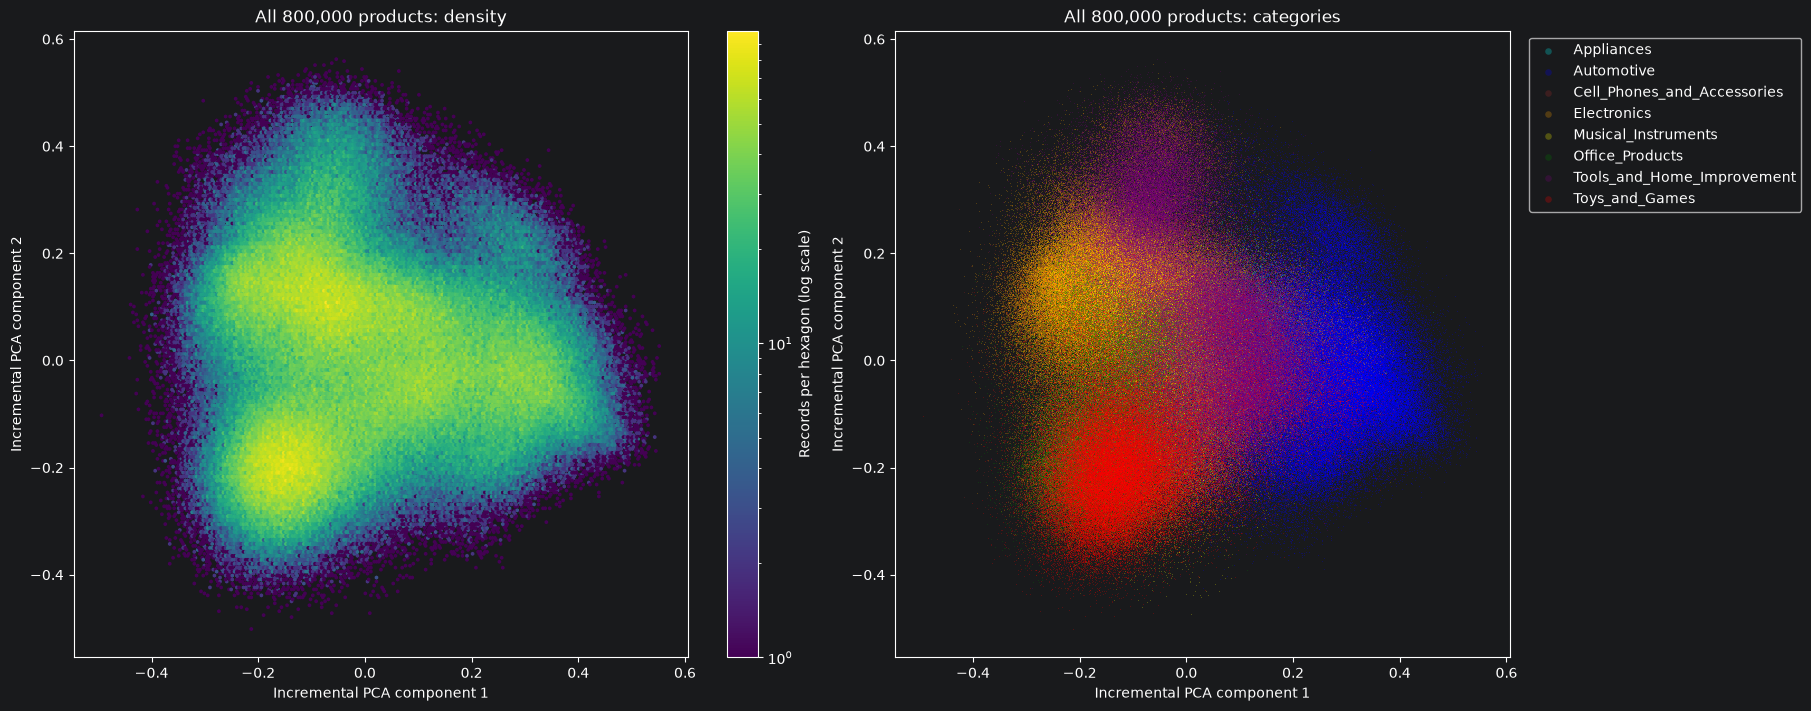

In [9]:
# Full-dataset visualization (all records)
#
# Chroma uses SQLite internally, so requesting all 800,000 records at once exceeds
# SQLite's bound-variable limit. Read the collection in safe pages instead.
# IncrementalPCA learns a 2D projection one page at a time, which avoids keeping
# every 384-dimensional embedding in memory. A second pass transforms every record.
# The final plots are rasterized/aggregated because 800,000 interactive Plotly
# markers (especially with hover text) would make the browser page very large.

from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt

FULL_DATASET_BATCH_SIZE = 10_000  # Verified to stay below this store's SQLite limit
total_records = collection.count()
offsets = range(0, total_records, FULL_DATASET_BATCH_SIZE)

# Pass 1: learn three principal components from every embedding.
# Components 1-2 power the 2D views; components 1-3 power the 3D view below.
ipca = IncrementalPCA(n_components=3, batch_size=FULL_DATASET_BATCH_SIZE)
for offset in tqdm(offsets, total=(total_records + FULL_DATASET_BATCH_SIZE - 1) // FULL_DATASET_BATCH_SIZE, desc='Fitting PCA'):
    page_size = min(FULL_DATASET_BATCH_SIZE, total_records - offset)
    page = collection.get(include=['embeddings'], limit=page_size, offset=offset)
    embedding_batch = np.asarray(page['embeddings'], dtype=np.float32)
    if len(embedding_batch):
        ipca.partial_fit(embedding_batch)

# Only the compact 3D coordinates and one category code per record are retained.
projected = np.empty((total_records, 3), dtype=np.float32)
category_codes = np.full(total_records, -1, dtype=np.int8)
category_to_code = {category: index for index, category in enumerate(CATEGORIES)}

def get_category_code(metadata):
    # Chroma metadata values have a broad declared type; only strings are valid here.
    category = metadata.get('category')
    return category_to_code.get(category, -1) if isinstance(category, str) else -1

records_read = 0

# Pass 2: transform every embedding and retain its category for coloring.
for offset in tqdm(offsets, total=(total_records + FULL_DATASET_BATCH_SIZE - 1) // FULL_DATASET_BATCH_SIZE, desc='Projecting all records'):
    page_size = min(FULL_DATASET_BATCH_SIZE, total_records - offset)
    page = collection.get(include=['embeddings', 'metadatas'], limit=page_size, offset=offset)
    embedding_batch = np.asarray(page['embeddings'], dtype=np.float32)
    batch_length = len(embedding_batch)
    if not batch_length:
        continue

    end = offset + batch_length
    projected[offset:end] = ipca.transform(embedding_batch).astype(np.float32)
    category_codes[offset:end] = [
        get_category_code(metadata)
        for metadata in page['metadatas']
    ]
    records_read += batch_length

# If the collection changed while this cell ran, discard any unused preallocated rows.
projected = projected[:records_read]
category_codes = category_codes[:records_read]

# Left: density of every record. Right: every record colored by product category.
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
density = axes[0].hexbin(
    projected[:, 0], projected[:, 1], gridsize=250, bins='log', mincnt=1, cmap='viridis'
)
fig.colorbar(density, ax=axes[0], label='Records per hexagon (log scale)')
axes[0].set_title(f'All {records_read:,} products: density')

for code, (category, color) in enumerate(zip(CATEGORIES, COLORS)):
    mask = category_codes == code
    axes[1].scatter(
        projected[mask, 0], projected[mask, 1],
        s=0.35, alpha=0.25, color=color, linewidths=0, rasterized=True, label=category
    )

for axis in axes:
    axis.set_xlabel('Incremental PCA component 1')
    axis.set_ylabel('Incremental PCA component 2')

axes[1].set_title(f'All {records_read:,} products: categories')
axes[1].legend(markerscale=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


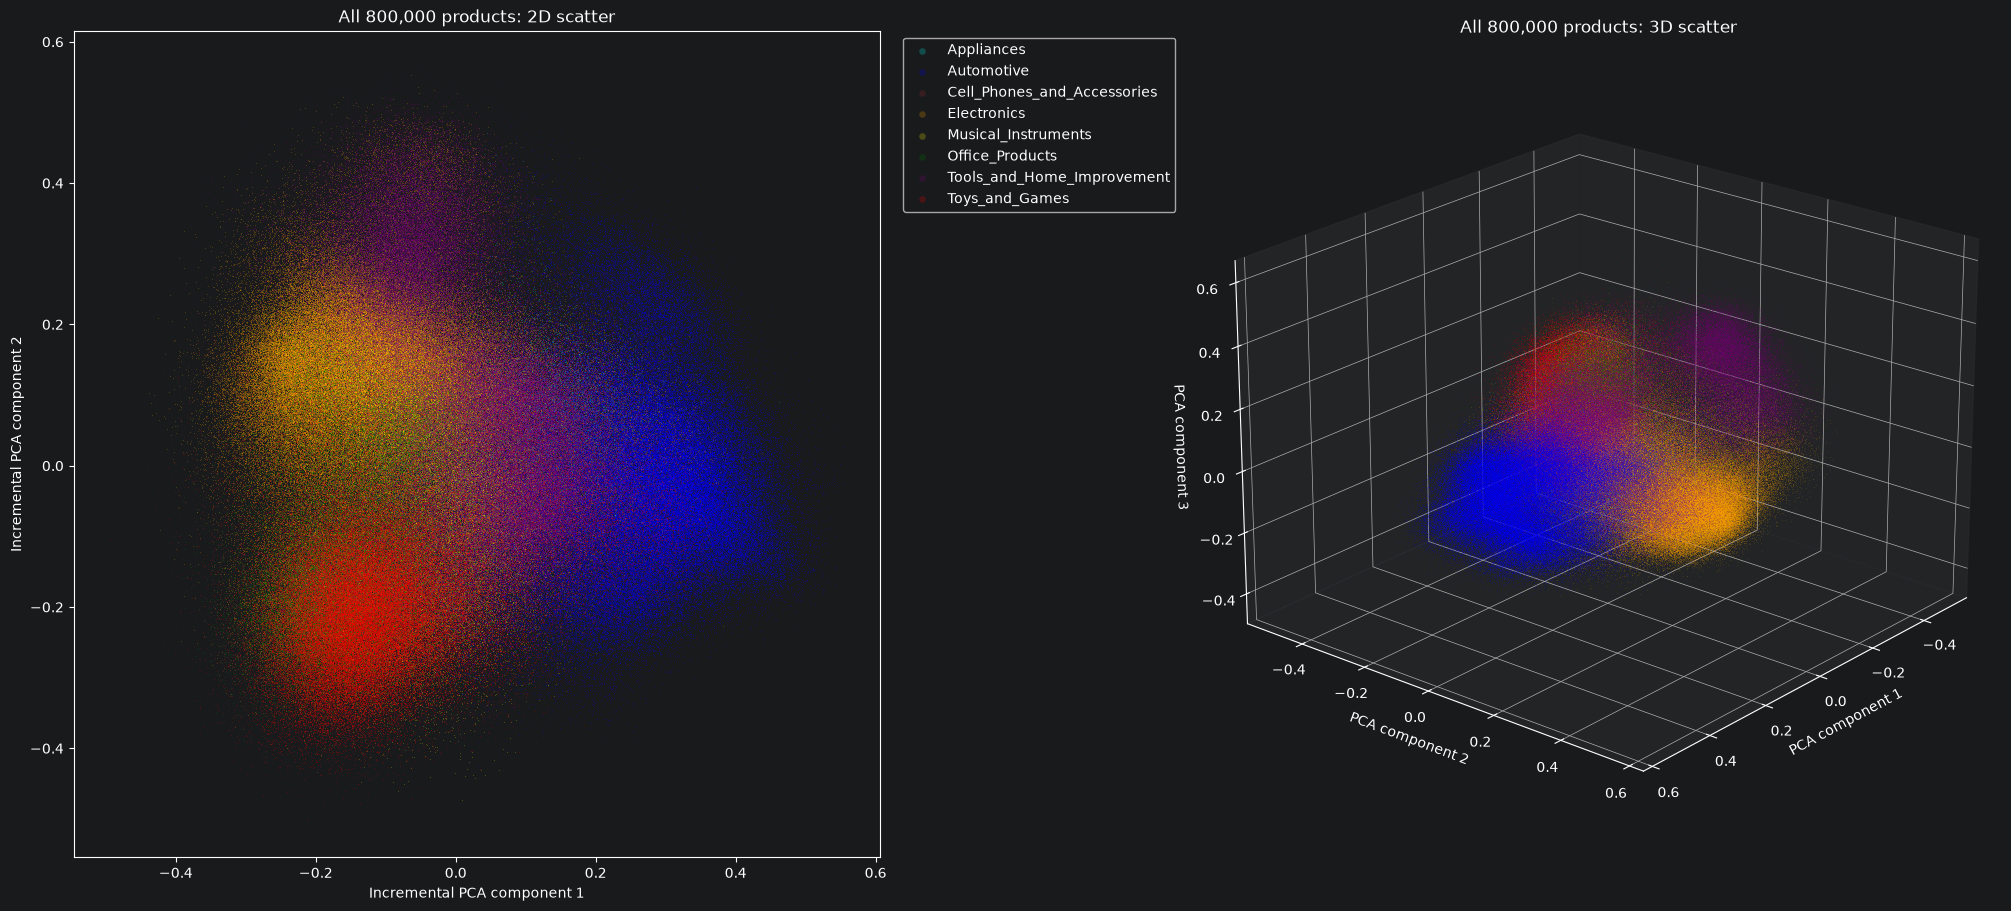

In [10]:
# Static 2D and 3D scatter plots of all records
#
# This cell reuses the three-component `projected` array created by the previous
# full-dataset cell. Every record is plotted, but the result is rasterized into
# the notebook output to avoid creating 800,000 interactive browser objects.
# Run the previous cell again after changing it from 2 to 3 PCA components.

if projected.ndim != 2 or projected.shape[1] < 3:
    raise RuntimeError('Run the preceding full-dataset cell to create a 3D PCA projection first.')

fig = plt.figure(figsize=(20, 9), constrained_layout=True)
axis_2d = fig.add_subplot(1, 2, 1)
axis_3d = fig.add_subplot(1, 2, 2, projection='3d')

for code, (category, color) in enumerate(zip(CATEGORIES, COLORS)):
    mask = category_codes == code

    # Small, translucent markers make dense regions visible in the 2D view.
    axis_2d.scatter(
        projected[mask, 0], projected[mask, 1],
        s=0.35, alpha=0.22, color=color, linewidths=0,
        rasterized=True, label=category
    )

    # Disable depth shading to reduce rendering work for the full 800k-point view.
    axis_3d.scatter(
        projected[mask, 0], projected[mask, 1], projected[mask, 2],
        s=0.25, alpha=0.18, color=color, linewidths=0,
        depthshade=False, rasterized=True
    )

axis_2d.set(
    title=f'All {len(projected):,} products: 2D scatter',
    xlabel='Incremental PCA component 1',
    ylabel='Incremental PCA component 2'
)
axis_2d.legend(markerscale=8, bbox_to_anchor=(1.02, 1), loc='upper left')

axis_3d.set(
    title=f'All {len(projected):,} products: 3D scatter',
    xlabel='PCA component 1',
    ylabel='PCA component 2',
    zlabel='PCA component 3'
)
axis_3d.view_init(elev=22, azim=40)

plt.show()


In [11]:
test[0]

def vector(item):
    return encoder.encode(item.summary)

def find_similars(item):
    vec = vector(item)
    results = collection.query(query_embeddings=vec.astype(float).tolist(), n_results=5)
    documents = results['documents'][0][:]
    prices = [m['price'] for m in results['metadatas'][0][:]]
    return documents, prices

find_similars(test[0])

(['Title: Old Blood Noise Endeavors Procession Reverb  \nCategory: Audio Effects  \nBrand: Old Blood Noise Endeavors  \nDescription: A compact, sci‑fi inspired reverb pedal with three modulation modes for creating otherworldly echo effects.  \nDetails: Features adjustable mix, decay, speed, depth, and footswitches for bypass and hold; powered by 9\u202fV DC with 60\u202fmA draw.',
  'Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  \nCategory: Music Equipment → Effects Pedals  \nBrand: Boss  \nDescription: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  \nDetails: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adjustable Tone knob, and 1\u202fMΩ input impedance.',
  'Title: Old Blood Noise Endeavors Mondegreen Delay Pedal  \nCategory: Musical Instruments / Effects Pedals  \nBrand: Old Blood Noise  \nDescription: A digital delay pedal that transforms your signal into creati

In [13]:
# We need to give some context to qwen by selecting 5 products with similar descriptions

def make_context(similars, prices):
    message = "For context, here are some other items that might be similar to the item you need to estimate.\n\n"
    for similar, price in zip(similars, prices):
        message += f"Potentially related product:\n{similar}\nPrice is ${price:.2f}\n\n"
    return message

documents, prices = find_similars(test[0])
print(make_context(documents, prices))

def messages_for(item, similars, prices):
    message = f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}\n\n"
    message += make_context(similars, prices)
    return [{"role": "user", "content": message}]

documents, prices = find_similars(test[0])
print(messages_for(test[0], documents, prices)[0]['content'])
# The function for gpt-5-mini
# Local Qwen configuration for LiteLLM.
# `ollama/` is required even though `ollama list` shows the bare model tag.
local_qwen_tag = os.getenv('PRICER_QWEN_MODEL', 'qwen3.6:latest').strip()
LOCAL_QWEN_MODEL = local_qwen_tag if local_qwen_tag.startswith('ollama/') else f'ollama/{local_qwen_tag}'
OLLAMA_API_BASE = os.getenv('OLLAMA_API_BASE', 'http://localhost:11434')

# RAG price estimator using the local Qwen model (no cloud API call).

def qwen_rag(item):
    documents, prices = find_similars(item)
    response = completion(
        model=LOCAL_QWEN_MODEL,
        api_base=OLLAMA_API_BASE,
        messages=messages_for(item, documents, prices),
        temperature=0,
        max_tokens=50,
        num_ctx=4096,
        think=False,
        keep_alive='30m',
        seed=42,
    )
    return response.choices[0].message.content
# How much does our favorite distortion pedal cost?

test[0].price
# Let's do this!!

qwen_rag(test[0])
# Start small when evaluating a large local model. Increase size after this succeeds.
# One worker prevents concurrent requests from competing for local RAM/VRAM.
evaluate(qwen_rag, test, size=20, workers=1)

import modal
Pricer = modal.Cls.from_name("pricer-service", "Pricer")
pricer = Pricer()

def specialist(item):
    return pricer.price.remote(item.summary)

def get_price(reply):
    reply = reply.replace("$", "").replace(",", "")
    match = re.search(r"[-+]?\d*\.\d+|\d+", reply)
    return float(match.group()) if match else 0

For context, here are some other items that might be similar to the item you need to estimate.

Potentially related product:
Title: Old Blood Noise Endeavors Procession Reverb  
Category: Audio Effects  
Brand: Old Blood Noise Endeavors  
Description: A compact, sci‑fi inspired reverb pedal with three modulation modes for creating otherworldly echo effects.  
Details: Features adjustable mix, decay, speed, depth, and footswitches for bypass and hold; powered by 9 V DC with 60 mA draw.
Price is $209.00

Potentially related product:
Title: Boss MD‑2 Mega Distortion Modulation Multi‑Effects Pedal  
Category: Music Equipment → Effects Pedals  
Brand: Boss  
Description: A powerful distortion pedal that delivers extreme low‑end crunch and endless sustain for metal and hard rock.  
Details: Features a Gain Boost circuit, bottom‑heavy Bottom control for 6/7‑string guitars, adjustable Tone knob, and 1 MΩ input impedance.
Price is $109.99

Potentially related product:
Title: Old Blood Noise End

  0%|          | 0/20 [00:00<?, ?it/s]

$10 $14 $25 $24 $5 $150 $16 $70 $11 $5 $43 $100 $0 $7 $10 $0 $5 $33 $43 $40 

C:\Users\aksha\PycharmProjects\PricerProje\venv\Lib\site-packages\modal\_utils\async_utils.py:42: DeprecationWarning: 'asyncio.WindowsSelectorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
C:\Users\aksha\PycharmProjects\PricerProje\venv\Lib\site-packages\modal\_utils\async_utils.py:42: DeprecationWarning: 'asyncio.set_event_loop_policy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())


In [22]:
from pathlib import Path
from agents.deep_neural_network import DeepNeuralNetworkInference

# This checkpoint is built locally; see BUILD_DEEP_NEURAL_NETWORK.md.
DNN_CHECKPOINT = Path('../artifacts/deep_neural_network.pth')
runner = None
if DNN_CHECKPOINT.exists():
    runner = DeepNeuralNetworkInference()
    runner.setup()
    runner.load(DNN_CHECKPOINT)
    print(f'Loaded local neural-network checkpoint: {DNN_CHECKPOINT}')
else:
    print(
        f'Skipping neural-network and ensemble evaluation because {DNN_CHECKPOINT} does not exist yet.\n'
        r'Train it locally with: python .\train_deep_neural_network.py --epochs 5'
    )

def deep_neural_network(item):
    if runner is None:
        raise RuntimeError('The local neural-network checkpoint has not been trained yet.')
    return runner.inference(item.summary)

def ensemble(item):
    price1 = get_price(qwen_rag(item))
    price2 = specialist(item)
    price3 = deep_neural_network(item)
    return price1 * 0.8 + price2 * 0.1 + price3 * 0.1

if runner is not None:
    evaluate(ensemble, test, size=20, workers=1)

root = logging.getLogger()
root.setLevel(logging.INFO)

import importlib
import agents.frontier_agent as frontier_agent_module
importlib.reload(frontier_agent_module)  # Pick up the local-Qwen implementation in this kernel
FrontierAgent = frontier_agent_module.FrontierAgent

agent = FrontierAgent(collection)
print(agent.price("Quadcast HyperX condenser mic, connects via usb-c to your computer for crystal clear audio"))
print(agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs"))

from agents.neural_network_agent import NeuralNetworkAgent
if DNN_CHECKPOINT.exists():
    agent = NeuralNetworkAgent()
    print(agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs"))

import agents.ensemble_agent as ensemble_agent_module
importlib.reload(ensemble_agent_module)  # Ensure its FrontierAgent also uses local Qwen
EnsembleAgent = ensemble_agent_module.EnsembleAgent
if DNN_CHECKPOINT.exists():
    agent = EnsembleAgent(collection)
    print(agent.price("Shure MV7+ professional podcaster microphone with usb-c and XLR outputs"))

INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is using local model ollama/qwen3.6:latest
INFO:sentence_transformers.base.model:No device provided, using cuda:0


Skipping neural-network and ensemble evaluation because artifacts\deep_neural_network.pth does not exist yet.
Train it locally with: python .\train_deep_neural_network.py --epochs 5


INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:root:[Frontier Agent] Frontier Agent is ready
INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


...

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call ollama/qwen3.6:latest with context including 5 similar products
14:09:06 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama
14:09:26 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $129.00
INFO:root:[Frontier Agent] Frontier Agent is performing a RAG search of the Chroma datastore to find 5 similar products


129.0


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:[Frontier Agent] Frontier Agent has found similar products
INFO:root:[Frontier Agent] Frontier Agent is about to call ollama/qwen3.6:latest with context including 5 similar products
14:09:29 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama
14:09:35 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
INFO:root:[Frontier Agent] Frontier Agent completed - predicting $349.00


349.0


In [24]:
import os
from dotenv import load_dotenv
# from openai import OpenAI
from agents.deals import ScrapedDeal, DealSelection
import logging
import requests
load_dotenv(override=True)
# openai = OpenAI()
MODEL = "qwen3.6:latest"
deals = ScrapedDeal.fetch(show_progress=True)
len(deals)
deals[10].describe()

100%|██████████| 3/3 [00:29<00:00,  9.87s/it]


"Title: Razer Cobra RGB 8500 DPI Wired Mouse for $18 + free shipping w/ Prime\nDetails: This Razer Cobra mouse is $12 off its regular price of $30 at Amazon. That's the lowest price we could find. It uses an 8500 DPI optical sensor with 50 DPI adjustment increments and optical switches rated for up to 90 million clicks. Prime members get free shipping.\xa0 Buy Now at Amazon\nFeatures: 8500 DPI optical sensor with 50 DPI adjustment increments Optical switches rated for up to 90 million clicks 0.2ms trigger response time Chroma RGB lighting with 16.8 million color options Speedflex cable for reduced drag during movement Weighs 5.6 oz.\nURL: https://www.dealnews.com/Razer-Cobra-RGB-8500-DPI-Wired-Mouse-for-18-free-shipping-w-Prime/21969869.html?iref=rss-c39"

In [25]:
SYSTEM_PROMPT = """You identify and summarize the 5 most detailed deals from a list, by selecting deals that have the most detailed, high quality description and the most clear price.
Respond strictly in JSON with no explanation, using this format. You should provide the price as a number derived from the description. If the price of a deal isn't clear, do not include that deal in your response.
Most important is that you respond with the 5 deals that have the most detailed product description with price. It's not important to mention the terms of the deal; most important is a thorough description of the product.
Be careful with products that are described as "$XXX off" or "reduced by $XXX" - this isn't the actual price of the product. Only respond with products when you are highly confident about the price.
"""

USER_PROMPT_PREFIX = """Respond with the most promising 5 deals from this list, selecting those which have the most detailed, high quality product description and a clear price that is greater than 0.
You should rephrase the description to be a summary of the product itself, not the terms of the deal.
Remember to respond with a short paragraph of text in the product_description field for each of the 5 items that you select.
Be careful with products that are described as "$XXX off" or "reduced by $XXX" - this isn't the actual price of the product. Only respond with products when you are highly confident about the price.

Deals:

"""

USER_PROMPT_SUFFIX = "\n\nInclude exactly 5 deals, no more."

In [29]:
# this makes a suitable user prompt given scraped deals

def make_user_prompt(scraped):
    user_prompt = USER_PROMPT_PREFIX
    user_prompt += '\n\n'.join([scrape.describe() for scrape in scraped])
    user_prompt += USER_PROMPT_SUFFIX
    return user_prompt
# Let's create a user prompt for the deals we just scraped, and look at how it begins

user_prompt = make_user_prompt(deals)
print(user_prompt[:2000])
messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": user_prompt}]
# response = openai.chat.completions.parse(model=MODEL, messages=messages, response_format=DealSelection, reasoning_effort="minimal")
# LiteLLM/Ollama returns structured JSON in message.content rather than message.parsed.
response = completion(
    model=LOCAL_QWEN_MODEL,
    api_base=OLLAMA_API_BASE,
    messages=messages,
    response_format=DealSelection,
    # Keep Qwen's reasoning trace out of the structured JSON response.
    think=False,
)
raw_content = response.choices[0].message.content
if not raw_content:
    raise ValueError('Local Qwen returned an empty structured response.')

# Some local models wrap otherwise-valid JSON in a Markdown code fence.
clean_content = raw_content.strip()
if clean_content.startswith('```'):
    clean_content = clean_content.split('\n', 1)[1]
    clean_content = clean_content.rsplit('```', 1)[0].strip()

# Validate into the same DealSelection structured-output format used by Deals/ScrapedDeal.
results = DealSelection.model_validate_json(clean_content)
# Display JSON in the DealSelection format: {deals: [{product_description, price, url}, ...]}.
print(results.model_dump_json(indent=2))
for deal in results.deals:
    print(deal.product_description)
    print(deal.price)
    print(deal.url)
    print()
root = logging.getLogger()
root.setLevel(logging.INFO)

Respond with the most promising 5 deals from this list, selecting those which have the most detailed, high quality product description and a clear price that is greater than 0.
You should rephrase the description to be a summary of the product itself, not the terms of the deal.
Remember to respond with a short paragraph of text in the product_description field for each of the 5 items that you select.
Be careful with products that are described as "$XXX off" or "reduced by $XXX" - this isn't the actual price of the product. Only respond with products when you are highly confident about the price. 

Deals:

Title: aMagisn Magnetic Invisible POV Neck Mount for $23 + free shipping
Details: Designed for POV-style video where you want a hands-free, chest-level camera angle without visible straps or harnesses, this magnetic neck mount attaches discreetly and works well for action footage, cooking demos, or DIY documentation. Apply coupon code "HW9RUY6H" for a savings of $15. Buy Now at Amazon

14:47:49 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama
14:48:28 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler


{
  "deals": [
    {
      "product_description": "The Apple MacBook Air features a 15.3-inch Liquid Retina display with a resolution of 2880x1864, powered by the M5 chip which includes a 10-core CPU and 10-core GPU. It is equipped with 24GB of unified memory and a 512GB SSD storage capacity. The device supports Wi-Fi 7 and Bluetooth 6, includes a 12MP Center Stage camera with Desk View, and offers two Thunderbolt 4 ports along with MagSafe 3 charging.",
      "price": 1499.0,
      "url": "https://www.dealnews.com/Apple-Mac-Book-Air-M5-15-3-Laptop-w-24-GB-2026-for-1-499-free-shipping/21969856.html?iref=rss-c39"
    },
    {
      "product_description": "The Samsung HW-Q600F is a 3.1.2-channel Dolby Atmos soundbar featuring up-firing speakers for immersive audio support. It includes a wireless subwoofer for deep bass, HDMI eARC and optical inputs, and Bluetooth connectivity. The system can be expanded with optional wireless rear speakers (sold separately) to create a full surround soun

In [31]:
# Original block (kept for reference)
# from agents.scanner_agent import ScannerAgent
# agent = ScannerAgent()
# result = agent.scan()
# result

# Local-Qwen replacement
# Reload the module so this running kernel uses the updated Ollama implementation.
import importlib
import agents.scanner_agent as scanner_agent_module
importlib.reload(scanner_agent_module)
ScannerAgent = scanner_agent_module.ScannerAgent

agent = ScannerAgent()
result = agent.scan()
result

INFO:root:[Scanner Agent] Scanner Agent is initializing
INFO:root:[Scanner Agent] Scanner Agent is ready using local model ollama/qwen3.6:latest
INFO:root:[Scanner Agent] Scanner Agent is about to fetch deals from RSS feed
INFO:root:[Scanner Agent] Scanner Agent received 30 deals not already scraped
INFO:root:[Scanner Agent] Scanner Agent is calling local model ollama/qwen3.6:latest using structured output
14:58:27 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama
14:59:03 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
INFO:root:[Scanner Agent] Scanner Agent received 5 selected deals with price>0 from local Qwen


DealSelection(deals=[Deal(product_description='Samsung HW-Q600F is a 3.1.2-channel Dolby Atmos soundbar featuring up-firing speakers for immersive surround sound. The system includes a wireless subwoofer for deep bass and supports DTS Virtual:X, HDMI eARC, optical, and Bluetooth inputs. It is expandable with optional wireless rear speakers to create a full home theater setup.', price=277.0, url='https://www.dealnews.com/Samsung-HW-Q600-F-3-1-2-Channel-Dolby-Atmos-Soundbar-for-277-free-shipping/21969864.html?iref=rss-c142'), Deal(product_description='This Apple MacBook Air features a 15.3-inch Liquid Retina display with 2880 x 1864 resolution, powered by the new M5 chip with a 10-core CPU and GPU. It includes 24GB of unified memory, 512GB SSD storage, a 12MP Center Stage camera, Wi-Fi 7, Bluetooth 6, two Thunderbolt 4 ports, and MagSafe 3 charging.', price=1499.0, url='https://www.dealnews.com/Apple-Mac-Book-Air-M5-15-3-Laptop-w-24-GB-2026-for-1-499-free-shipping/21969856.html?iref=rss-

In [32]:
# Original phone/Pushover block (disabled and kept for reference)
# load_dotenv(override=True)
# pushover_user = os.getenv('PUSHOVER_USER')
# pushover_token = os.getenv('PUSHOVER_TOKEN')
# pushover_url = "https://api.pushover.net/1/messages.json"
# if pushover_user:
#     print(f"Pushover user found and starts with {pushover_user[0]}")
# else:
#     print("Pushover user not found")
# if pushover_token:
#     print(f"Pushover token found and starts with {pushover_token[0]}")
# else:
#     print("Pushover token not found")
# def push(message):
#     print(f"Push: {message}")
#     payload = {"user": pushover_user, "token": pushover_token, "message": message}
#     requests.post(pushover_url, data=payload)
# push("MASSIVE DEAL!!")

# Local-only replacement: no phone, API key, or cloud messaging service.
# Reload the module so this running notebook kernel sees the updated local implementation.
import importlib
from IPython.display import HTML, display
import agents.messaging_agent as messaging_agent_module

importlib.reload(messaging_agent_module)
MessagingAgent = messaging_agent_module.MessagingAgent

agent = MessagingAgent()
agent.notify(
    description="A special deal on Samsung 60-inch LED TV going at a great bargain",
    deal_price=300,
    estimated_true_value=1000,
    url="https://www.samsung.com",
)

# Render the local dashboard directly inside PyCharm's notebook output.
display(HTML(agent.html_path.read_text(encoding="utf-8")))
print(f"Browser-ready local page: {agent.html_path.resolve()}")

INFO:root:[Messaging Agent] Messaging Agent is initializing with local alerts
INFO:root:[Messaging Agent] Local alert page: C:\Users\aksha\PycharmProjects\PricerProject\artifacts\deal_alerts.html
INFO:root:[Messaging Agent] Messaging Agent published a local alert



=== LOCAL DEAL ALERT ===
Deal: A special deal on Samsung 60-inch LED TV going at a great bargain
Price: $300.00
Estimated value: $1,000.00
Estimated discount: $700.00
Dashboard: C:\Users\aksha\PycharmProjects\PricerProject\artifacts\deal_alerts.html



Browser-ready local page: C:\Users\aksha\PycharmProjects\PricerProject\artifacts\deal_alerts.html


In [33]:
# Original tutorial/mock block (disabled and kept for reference)
# test_results = ScannerAgent().test_scan()
# def scan_the_internet_for_bargains() -> str:
#     print("Fake function to scan the internet - this returns hardcoded deals")
#     return test_results.model_dump_json()
# def estimate_true_value(description: str) -> str:
#     print(f"Fake estimator for {description[:20]}... - always returns $300")
#     return f"Product {description} has an estimated true value of $300"
# def notify_user_of_deal(description, deal_price, estimated_true_value, url):
#     print("Fake notification")
#     return "notification sent ok"

# Real local implementations used by the Qwen tool-calling loop below.
# FrontierAgent retrieves comparable products from Chroma and asks local Qwen
# for a product-specific estimate; it does not use a static fallback price.
from agents.frontier_agent import FrontierAgent
from agents.messaging_agent import MessagingAgent

tool_scanner = ScannerAgent()
tool_estimator = FrontierAgent(
    collection,
    model_name=LOCAL_QWEN_MODEL,
    api_base=OLLAMA_API_BASE,
)
tool_messenger = MessagingAgent()

def scan_the_internet_for_bargains() -> dict:
    """Scrape and select current deals using the local ScannerAgent."""
    selection = tool_scanner.scan()
    return selection.model_dump() if selection else {"deals": []}

def estimate_true_value(description: str) -> dict:
    """Estimate value from comparable products using local Qwen."""
    estimate = round(float(tool_estimator.price(description)), 2)
    return {
        "description": description,
        "estimated_true_value": estimate,
    }

def notify_user_of_deal(
    description: str,
    deal_price: float,
    estimated_true_value: float,
    url: str,
) -> dict:
    """Write the selected deal to the local console and HTML dashboard."""
    tool_messenger.notify(description, deal_price, estimated_true_value, url)
    return {"status": "local notification saved"}

INFO:root:[Scanner Agent] Scanner Agent is initializing
INFO:root:[Scanner Agent] Scanner Agent is ready using local model ollama/qwen3.6:latest


In [35]:
# Original mock checks (disabled because the tools are now real)
# print(notify_user_of_deal("a new iphone", 100, 1000, "https://www.apple.com/iphone"))
# print(test_results)

# Avoid generating a fake alert or spending inference time during setup.
print(f"Real local tools ready with estimator model: {tool_estimator.MODEL}")

Fake function to notify user of a new iphone which costs 100 and estimate is 1000
notification sent ok
deals=[Deal(product_description="The Hisense R6 Series 55R6030N is a 55-inch 4K UHD Roku Smart TV that offers stunning picture quality with 3840x2160 resolution. It features Dolby Vision HDR and HDR10 compatibility, ensuring a vibrant and dynamic viewing experience. The TV runs on Roku's operating system, allowing easy access to streaming services and voice control compatibility with Google Assistant and Alexa. With three HDMI ports available, connecting multiple devices is simple and efficient.", price=178.0, url='https://www.dealnews.com/products/Hisense/Hisense-R6-Series-55-R6030-N-55-4-K-UHD-Roku-Smart-TV/484824.html?iref=rss-c142'), Deal(product_description='The Poly Studio P21 is a 21.5-inch LED personal meeting display designed specifically for remote work and video conferencing. With a native resolution of 1080p, it provides crystal-clear video quality, featuring a privacy shu

In [36]:
scan_function = {
        "name": "scan_the_internet_for_bargains",
        "description": "Returns top bargains scraped from the internet along with the price each item is being offered for",
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
            "additionalProperties": False
        }
    }

estimate_function = {
    "name": "estimate_true_value",
    "description": "Given the description of an item, estimate how much it is actually worth",
    "parameters": {
        "type": "object",
        "properties": {
            "description": {
                "type": "string",
                "description": "The description of the item to be estimated"
            },
        },
        "required": ["description"],
        "additionalProperties": False
    }
}

notify_function = {
    "name": "notify_user_of_deal",
    "description": "Save a local dashboard alert about the single most compelling deal; only call this one time",
    "parameters": {
        "type": "object",
        "properties": {
            "description": {
                "type": "string",
                "description": "The description of the item itself scraped from the internet"
            },
            "deal_price": {
                "type": "number",
                "description": "The price offered by this deal scraped from the internet"
            }
            ,
            "estimated_true_value": {
                "type": "number",
                "description": "The estimated actual value that this is worth"
            }
            ,
            "url": {
                "type": "string",
                "description": "The URL of this deal as scraped from the internet"
            }
        },
        "required": ["description", "deal_price", "estimated_true_value", "url"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": scan_function},
 {"type": "function", "function": estimate_function},
 {"type": "function", "function": notify_function}
 ]
tools

[{'type': 'function',
  'function': {'name': 'scan_the_internet_for_bargains',
   'description': 'Returns top bargains scraped from the internet along with the price each item is being offered for',
   'parameters': {'type': 'object',
    'properties': {},
    'required': [],
    'additionalProperties': False}}},
 {'type': 'function',
  'function': {'name': 'estimate_true_value',
   'description': 'Given the description of an item, estimate how much it is actually worth',
   'parameters': {'type': 'object',
    'properties': {'description': {'type': 'string',
      'description': 'The description of the item to be estimated'}},
    'required': ['description'],
    'additionalProperties': False}}},
 {'type': 'function',
  'function': {'name': 'notify_user_of_deal',
   'description': 'Send the user a push notification about the single most compelling deal; only call this one time',
   'parameters': {'type': 'object',
    'properties': {'description': {'type': 'string',
      'description

In [37]:
import json

def handle_tool_call(message):
    """
    Actually call the tools associated with this message
    """
    results = []
    for tool_call in message.tool_calls:
        tool_name = tool_call.function.name
        arguments = json.loads(tool_call.function.arguments)
        tool = globals().get(tool_name)
        result = tool(**arguments) if tool else {}
        results.append({"role": "tool","content": json.dumps(result),"tool_call_id": tool_call.id})
    return results
system_message = "You find great deals on bargain products using your tools, and notify the user of the best bargain."
user_message = """
First, use your tool to scan the internet for bargain deals. Then for each deal, use your tool to estimate its true value.
Then pick the single most compelling deal where the price is much lower than the estimated true value, and use your tool to notify the user.
Then just reply OK to indicate success.
"""
messages = [{"role": "system", "content": system_message},{"role": "user", "content": user_message}]
messages

[{'role': 'system',
  'content': 'You find great deals on bargain products using your tools, and notify the user of the best bargain.'},
 {'role': 'user',
  'content': '\nFirst, use your tool to scan the internet for bargain deals. Then for each deal, use your tool to estimate its true value.\nThen pick the single most compelling deal where the price is much lower than the estimated true value, and use your tool to notify the user.\nThen just reply OK to indicate success.\n'}]

In [38]:
done = False
while not done:
    # response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    response = completion(
    model=LOCAL_QWEN_MODEL,
    api_base=OLLAMA_API_BASE,
    messages=messages,
    tools=tools,
    # Keep Qwen's reasoning trace out of the structured JSON response.
    think=False,
)
    if response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        results = handle_tool_call(message)
        messages.append(message)
        messages.extend(results)
    else:
        done = True
response.choices[0].message.content



15:28:06 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama
15:28:22 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler


Fake function to scan the internet - this returns a hardcoded set of deals


15:28:24 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama
15:28:28 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
15:28:28 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama


Fake function to estimating true value of The Hisense R6 Serie... - this always returns $300


15:28:31 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
15:28:31 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama


...

Fake function to notify user of The Poly Studio P21 is a 21.5-inch LED personal meeting display designed specifically for remote work and video conferencing. which costs 30 and estimate is 300


15:30:24 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
15:30:24 - LiteLLM:INFO: utils.py:3840 - 
LiteLLM completion() model= qwen3.6:latest; provider = ollama
INFO:LiteLLM:
LiteLLM completion() model= qwen3.6:latest; provider = ollama


Fake function to notify user of The Poly Studio P21 is a 21.5-inch LED personal meeting display designed specifically for remote work and video conferencing. which costs 30 and estimate is 300


15:30:29 - LiteLLM:INFO: utils.py:1479 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler


'{"id": "call_8f4a1b2c-9d3e-4f5a-b6c7-d8e9f0a1b2c3", "type": "function", "function": {"name": "notify_user_of_deal", "arguments": {"description": "The Poly Studio P21 is a 21.5-inch LED personal meeting display designed specifically for remote work and video conferencing.", "deal_price": 30, "estimated_true_value": 300, "url": "https://www.dealnews.com/products/Poly-Studio-P21-21-5-1080-p-LED-Personal-Meeting-Display/378335.html?iref=rss-c39"}}}'

In [41]:
# Original block (kept for reference)
# root = logging.getLogger()
# root.setLevel(logging.INFO)
# DB = "products_vectorstore"
# client = chromadb.PersistentClient(path=DB)
# collection = client.get_or_create_collection('products')
# from agents.autonomous_planning_agent import AutonomousPlanningAgent
# agent = AutonomousPlanningAgent(collection)
# agent.plan()

# Local-Qwen replacement: orchestration and price estimation stay on this computer.
# The autonomous agent uses Qwen through Ollama for tool calls and the existing
# EnsembleAgent for non-static, product-specific price estimates.
import importlib
import logging
import chromadb
import agents.autonomous_planning_agent as autonomous_agent_module

importlib.reload(autonomous_agent_module)
AutonomousPlanningAgent = autonomous_agent_module.AutonomousPlanningAgent

root = logging.getLogger()
root.setLevel(logging.INFO)
PROJECT_ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()).lower() == "notebooks" else ".")
DB = os.path.join(PROJECT_ROOT, "products_vectorstore")
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection("products")

# Defaults to local qwen3.6:latest and http://localhost:11434.
# Optional overrides: PRICER_AUTONOMOUS_MODEL and OLLAMA_API_BASE.
agent = AutonomousPlanningAgent(collection)
opportunity = agent.plan()
opportunity

INFO:root:[Autonomous Planning Agent] Autonomous Planning Agent is initializing
INFO:root:[Scanner Agent] Scanner Agent is initializing
INFO:root:[Scanner Agent] Scanner Agent is ready using local model ollama/qwen3.6:latest
INFO:root:[Ensemble Agent] Initializing Ensemble Agent
INFO:root:[Specialist Agent] Specialist Agent is initializing - using local fine-tuned Qwen
INFO:root:[Frontier Agent] Initializing Frontier Agent
INFO:root:[Frontier Agent] Frontier Agent is using local model ollama/qwen3.6:latest
INFO:sentence_transformers.base.model:No device provided, using cuda:0
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:root:[Frontier Agent] Frontier Agent is ready
INFO:root:[Neural Network Agent] Neural Network Agent is initializing
INFO:root:Neural Network is using cuda
INFO:root:[Neural Network Agent] Neural Network Agent is ready and weights are loaded
INFO:root:[Ensemble Agent] Ensemble Agent is ready
INFO:root:[Messaging Agent] Messaging Agent is initializing with local alerts
INFO:root:[Messaging Agent] Local alert page: C:\Users\aksha\PycharmProjects\PricerProject\artifacts\deal_alerts.html
INFO:root:[Autonomous Planning Agent] Autonomous Planning Agent is ready using local model ollama/qwen3.6:latest
INFO:root:[Autonomous Planning Agent] Autonomous Planning Agent is kicking of

In [42]:
import gradio as gr
from deal_agent_framework import DealAgentFramework
from agents.deals import Opportunity, Deal
with gr.Blocks(title="The Price is Right", fill_width=True) as ui:

    with gr.Row():
        gr.Markdown('<div style="text-align: center;font-size:24px">The Price is Right - Deal Hunting Agentic AI</div>')
    with gr.Row():
        gr.Markdown('<div style="text-align: center;font-size:14px">Autonomous agent framework that finds online deals, collaborating with a proprietary fine-tuned LLM deployed on Modal, and a RAG pipeline with a frontier model and Chroma.</div>')


ui.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [43]:
# Updated to change from height to max_height due to change in Gradio v5
# With much thanks to student Ed B. for raising this

with gr.Blocks(title="The Price is Right", fill_width=True) as ui:

    initial_deal = Deal(product_description="Example description", price=100.0, url="https://cnn.com")
    initial_opportunity = Opportunity(deal=initial_deal, estimate=200.0, discount=100.0)
    opportunities = gr.State([initial_opportunity])

    def get_table(opps):
        return [[opp.deal.product_description, opp.deal.price, opp.estimate, opp.discount, opp.deal.url] for opp in opps]

    with gr.Row():
        gr.Markdown('<div style="text-align: center;font-size:24px">"The Price is Right" - Deal Hunting Agentic AI</div>')
    with gr.Row():
        gr.Markdown('<div style="text-align: center;font-size:14px">Deals surfaced so far:</div>')
    with gr.Row():
        opportunities_dataframe = gr.Dataframe(
            headers=["Description", "Price", "Estimate", "Discount", "URL"],
            wrap=True,
            column_widths=[4, 1, 1, 1, 2],
            row_count=10,
            col_count=5,
            max_height=400,
        )

    ui.load(get_table, inputs=[opportunities], outputs=[opportunities_dataframe])

ui.launch(inbrowser=True)

C:\Users\aksha\PycharmProjects\PricerProje\venv\Lib\site-packages\gradio\components\dataframe.py:192: UserWarning: The `col_count` parameter is deprecated and will be removed. Please use `column_count` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [44]:
agent_framework = DealAgentFramework()
agent_framework.init_agents_as_needed()

with gr.Blocks(title="The Price is Right", fill_width=True) as ui:

    initial_deal = Deal(product_description="Example description", price=100.0, url="https://cnn.com")
    initial_opportunity = Opportunity(deal=initial_deal, estimate=200.0, discount=100.0)
    opportunities = gr.State([initial_opportunity])

    def get_table(opps):
        return [[opp.deal.product_description, opp.deal.price, opp.estimate, opp.discount, opp.deal.url] for opp in opps]

    def do_select(opportunities, selected_index: gr.SelectData):
        row = selected_index.index[0]
        opportunity = opportunities[row]
        agent_framework.planner.messenger.alert(opportunity)

    with gr.Row():
        gr.Markdown('<div style="text-align: center;font-size:24px">"The Price is Right" - Deal Hunting Agentic AI</div>')
    with gr.Row():
        gr.Markdown('<div style="text-align: center;font-size:14px">Deals surfaced so far:</div>')
    with gr.Row():
        opportunities_dataframe = gr.Dataframe(
            headers=["Description", "Price", "Estimate", "Discount", "URL"],
            wrap=True,
            column_widths=[4, 1, 1, 1, 2],
            row_count=10,
            col_count=5,
            max_height=400,
        )

    ui.load(get_table, inputs=[opportunities], outputs=[opportunities_dataframe])
    opportunities_dataframe.select(do_select, inputs=[opportunities], outputs=[])

ui.launch(inbrowser=True)

INFO:root:[Agent Framework] Initializing Agent Framework


[2026-08-04 16:37:47 -0700] [Agents] [INFO] [Agent Framework] Initializing Agent Framework


INFO:root:[Planning Agent] Planning Agent is initializing


[2026-08-04 16:37:47 -0700] [Agents] [INFO] [Planning Agent] Planning Agent is initializing


INFO:root:[Scanner Agent] Scanner Agent is initializing


...

[2026-08-04 16:37:51 -0700] [Agents] [INFO] [Planning Agent] Planning Agent is ready


INFO:root:[Agent Framework] Agent Framework is ready


[2026-08-04 16:37:51 -0700] [Agents] [INFO] [Agent Framework] Agent Framework is ready


C:\Users\aksha\PycharmProjects\PricerProje\venv\Lib\site-packages\gradio\components\dataframe.py:192: UserWarning: The `col_count` parameter is deprecated and will be removed. Please use `column_count` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [45]:
# Reset memory back to 2 deals discovered in the past

from deal_agent_framework import DealAgentFramework
DealAgentFramework.reset_memory()

import logging
root = logging.getLogger()
root.setLevel(logging.INFO)

In [1]:
!..\.venv\Scripts\python.exe ..\price_is_right.py

^C


# Optional: train the price model and push it to Hugging Face Hub

Run this section in order on an NVIDIA GPU. It fine-tunes `Qwen/Qwen2.5-3B-Instruct` with QLoRA using the prepared prompt dataset. The lite configuration is suitable for a first run; set `FT_LITE_MODE = False` only when you have enough GPU time and memory.

Before running, put `HF_TOKEN` in `.env`. `WANDB_API_KEY` is optional. The token needs permission to create and write model repositories.

In [3]:
from datetime import datetime
import os

import torch
import wandb
from datasets import load_dataset
from dotenv import load_dotenv
from huggingface_hub import login
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from trl import SFTConfig, SFTTrainer

load_dotenv(override=True)
if not torch.cuda.is_available():
    raise RuntimeError("QLoRA training requires an NVIDIA CUDA GPU.")

FT_BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"
FT_HF_USER = os.getenv("HF_USER", "akshaymgupte87")
FT_LITE_MODE = True
FT_DATASET_NAME = (
    "ed-donner/items_prompts_lite"
    if FT_LITE_MODE
    else "ed-donner/items_prompts_full"
)
FT_RUN_NAME = f"price-{datetime.now():%Y-%m-%d_%H.%M.%S}"
if FT_LITE_MODE:
    FT_RUN_NAME += "-lite"
FT_HUB_MODEL_ID = f"{FT_HF_USER}/{FT_RUN_NAME}"
FT_LOG_TO_WANDB = bool(os.getenv("WANDB_API_KEY"))

print(f"Dataset: {FT_DATASET_NAME}")
print(f"Destination: https://huggingface.co/{FT_HUB_MODEL_ID}")

Dataset: ed-donner/items_prompts_lite
Destination: https://huggingface.co/akshaymgupte87/price-2026-08-05_11.17.28-lite


In [4]:
# Authenticate and load the prompt/completion dataset.
hf_token = os.getenv("HF_TOKEN")
if not hf_token:
    raise RuntimeError("Set HF_TOKEN in .env before training.")
login(token=hf_token, add_to_git_credential=False)

ft_dataset = load_dataset(FT_DATASET_NAME, token=hf_token)
ft_train = ft_dataset["train"]
ft_validation_split = "validation" if "validation" in ft_dataset else "val"
ft_validation = ft_dataset[ft_validation_split].select(
    range(min(500 if FT_LITE_MODE else 1000, len(ft_dataset[ft_validation_split])))
)

if FT_LOG_TO_WANDB:
    os.environ["WANDB_PROJECT"] = "price"
    os.environ["WANDB_LOG_MODEL"] = "false"
    os.environ["WANDB_WATCH"] = "false"
    wandb.login(key=os.environ["WANDB_API_KEY"])
    wandb.init(project="price", name=FT_RUN_NAME)

print(ft_dataset)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\aksha\_netrc
wandb: Currently logged in as: akshay-mohan-gupte (akshay-mohan-gupte-red-oak-technologies) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 20000
    })
    val: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 1000
    })
})


In [5]:
# Load the base model in 4-bit precision.
set_seed(42)
ft_use_bf16 = torch.cuda.get_device_capability()[0] >= 8
ft_quantization = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if ft_use_bf16 else torch.float16,
    bnb_4bit_quant_type="nf4",
)
ft_tokenizer = AutoTokenizer.from_pretrained(FT_BASE_MODEL, trust_remote_code=True)
ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_tokenizer.padding_side = "right"
ft_base_model = AutoModelForCausalLM.from_pretrained(
    FT_BASE_MODEL,
    quantization_config=ft_quantization,
    device_map="auto",
)
ft_base_model.generation_config.pad_token_id = ft_tokenizer.pad_token_id
print(f"Model memory footprint: {ft_base_model.get_memory_footprint() / 1e6:.1f} MB")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model memory footprint: 2010.1 MB


In [6]:
# Configure LoRA and supervised fine-tuning.
ft_lora_rank = 32 if FT_LITE_MODE else 256
ft_target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"]
if not FT_LITE_MODE:
    ft_target_modules += ["gate_proj", "up_proj", "down_proj"]

ft_lora_config = LoraConfig(
    r=ft_lora_rank,
    lora_alpha=ft_lora_rank * 2,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=ft_target_modules,
)

ft_training_args = SFTConfig(
    output_dir=FT_RUN_NAME,
    num_train_epochs=1 if FT_LITE_MODE else 3,
    per_device_train_batch_size=32 if FT_LITE_MODE else 256,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    learning_rate=1e-4,
    weight_decay=0.001,
    warmup_ratio=0.01,
    lr_scheduler_type="cosine",
    max_grad_norm=0.3,
    fp16=not ft_use_bf16,
    bf16=ft_use_bf16,
    max_length=256,
    dataset_text_field="text",
    logging_steps=5 if FT_LITE_MODE else 10,
    eval_strategy="steps",
    eval_steps=100 if FT_LITE_MODE else 200,
    save_strategy="steps",
    save_steps=100 if FT_LITE_MODE else 200,
    save_total_limit=10,
    report_to="wandb" if FT_LOG_TO_WANDB else "none",
    run_name=FT_RUN_NAME,
    push_to_hub=True,
    hub_strategy="every_save",
    hub_model_id=FT_HUB_MODEL_ID,
    hub_private_repo=True,
    hub_token=hf_token,
)

ft_trainer = SFTTrainer(
    model=ft_base_model,
    args=ft_training_args,
    train_dataset=ft_train,
    eval_dataset=ft_validation,
    processing_class=ft_tokenizer,
    peft_config=ft_lora_config,
)
ft_trainer

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

## Start training and upload

The next cell performs the expensive operation. Checkpoints are uploaded every 100 lite-mode steps (200 in full mode), and the final call uploads the completed adapter and model card. If a run is interrupted, rerun the setup cells and pass the latest local checkpoint to `ft_trainer.train(resume_from_checkpoint=...)`.

In [7]:
# Train, save the final adapter locally, and publish it to Hugging Face Hub.
ft_train_result = ft_trainer.train()
ft_trainer.save_model(FT_RUN_NAME)
ft_trainer.push_to_hub(commit_message="Complete QLoRA price-model training")

if FT_LOG_TO_WANDB:
    wandb.finish()

print(f"Training complete: {ft_train_result.metrics}")
print(f"Model uploaded to https://huggingface.co/{FT_HUB_MODEL_ID}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.805944,0.807897,0.824459,350514.000000,0.717829
200,0.786682,0.797741,0.771433,701007.000000,0.722800
300,0.792451,0.787326,0.795817,1050860.000000,0.722895
400,0.791032,0.784764,0.805156,1399618.000000,0.724229
500,0.785297,0.784025,0.787421,1750647.000000,0.723371
600,0.801601,0.784577,0.790947,2101023.000000,0.722324
625,0.786852,0.783963,0.791422,2188770.000000,0.722990


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


eval/entropy,█▁▄▅▃▄▄
eval/loss,█▅▂▁▁▁▁
eval/mean_token_accuracy,▁▆▇█▇▆▇
eval/num_tokens,▁▂▄▅▆██
eval/runtime,█▁▅▅▄█▅
eval/samples_per_second,▁█▄▃▅▁▄
eval/steps_per_second,▁█▄▃▅▁▄
train/entropy,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
+5,...


Training complete: {'train_runtime': 1604.2104, 'train_samples_per_second': 12.467, 'train_steps_per_second': 0.39, 'total_flos': 4.79109992349696e+16, 'train_loss': 0.8673154407501221, 'epoch': 1.0}
Model uploaded to https://huggingface.co/akshaymgupte87/price-2026-08-05_11.17.28-lite
